In [2]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import json
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
warnings.filterwarnings("ignore")

In [3]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [13]:
adata_p = adata[adata.obs['image_ID'].str.contains('IMC18')].copy()
adata_p

AnnData object with n_obs × n_vars = 24997 × 33
    obs: 'Object', 'area', 'Y_centroid', 'X_centroid', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'distance_to_bone', 'image_ID', 'disease', 'patient_ID', 'ROI', 'disease2', 'distance_to_bone_corrected', 'cellcharter_CN', 'Phenotype4', 'HistoneH3', 'disease3'
    var: 'name', 'channel', 'deepcell', 'mean', 'std'
    uns: 'Phenotype4_colors', 'cellcharter_CN_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'arcsinh', 'zscore'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [14]:
adata_p.obs['image_ID'].unique()

['TS-373_IMC18-2_UB_001.csv', 'TS-373_IMC18-1_MGUS_001.csv', 'TS-373_IMC18-2_UB_002.csv', 'TS-373_IMC18-1_MGUS_002.csv']
Categories (4, object): ['TS-373_IMC18-1_MGUS_001.csv', 'TS-373_IMC18-1_MGUS_002.csv', 'TS-373_IMC18-2_UB_001.csv', 'TS-373_IMC18-2_UB_002.csv']

In [42]:
disease_mapping = adata_p.obs[['image_ID', 'disease3']].drop_duplicates().reset_index(drop=True)
disease_mapping

,image_ID,disease3
0,TS-373_IMC18-2_UB_001.csv,MM
1,TS-373_IMC18-1_MGUS_001.csv,SMM
2,TS-373_IMC18-2_UB_002.csv,MM
3,TS-373_IMC18-1_MGUS_002.csv,SMM


In [58]:
df = pd.crosstab(
    index=adata_p.obs['image_ID'],
    columns=adata_p.obs['Phenotype4'],
    normalize='index'
).reset_index()
df = df.melt(id_vars='image_ID')

In [59]:
df['disease3'] = df['image_ID'].map(disease_mapping.set_index('image_ID')['disease3'])
df

,image_ID,Phenotype4,value,disease3
0,TS-373_IMC18-1_MGUS_001.csv,Adipocytes,0.018960,SMM
1,TS-373_IMC18-1_MGUS_002.csv,Adipocytes,0.045274,SMM
2,TS-373_IMC18-2_UB_001.csv,Adipocytes,0.058868,MM
3,TS-373_IMC18-2_UB_002.csv,Adipocytes,0.037687,MM
4,TS-373_IMC18-1_MGUS_001.csv,CD4 T,0.029181,SMM
5,TS-373_IMC18-1_MGUS_002.csv,CD4 T,0.030183,SMM
6,TS-373_IMC18-2_UB_001.csv,CD4 T,0.030648,MM
7,TS-373_IMC18-2_UB_002.csv,CD4 T,0.021455,MM
8,TS-373_IMC18-1_MGUS_001.csv,CD8 T,0.023996,SMM
9,TS-373_IMC18-1_MGUS_002.csv,CD8 T,0.035107,SMM


Text(0.5, 1.0, 'Patient 18')

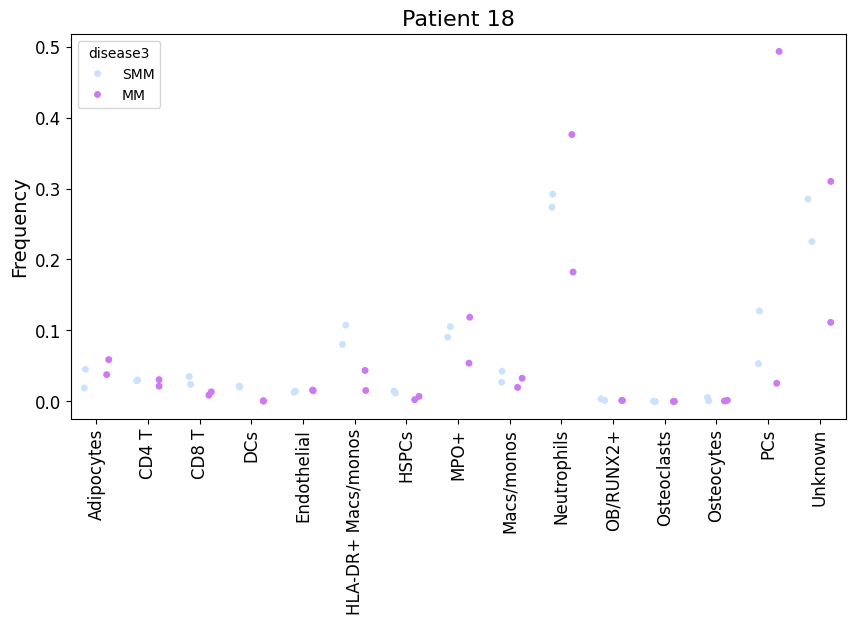

In [60]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='Phenotype4', y='value', hue='disease3', palette=disease3_color_map, hue_order=['SMM', 'MM'], dodge=True, jitter=True, size=5, ax=ax)
plt.xlabel('')
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.title('Patient 18', fontsize=16)

(0.0, 0.2)

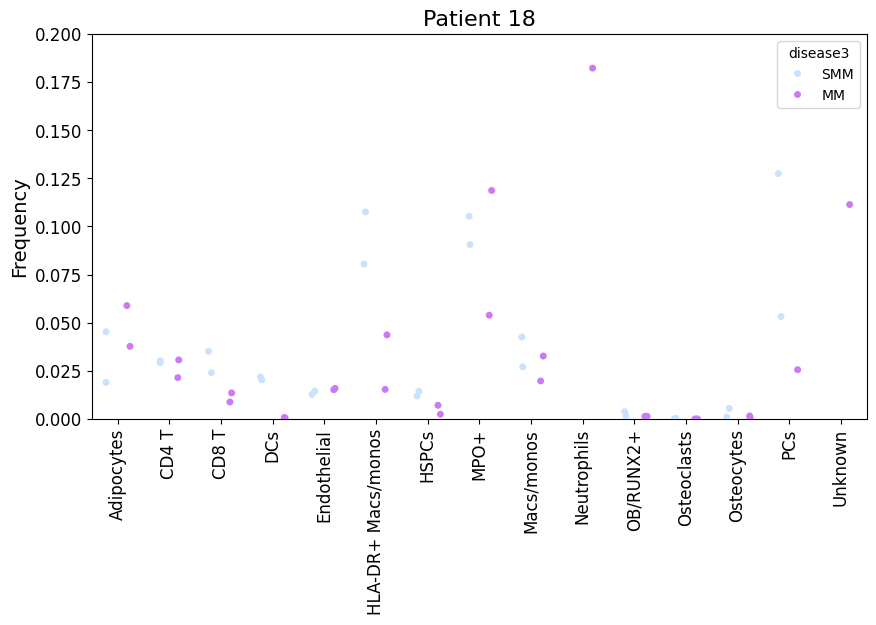

In [61]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='Phenotype4', y='value', hue='disease3', palette=disease3_color_map, hue_order=['SMM', 'MM'], dodge=True, jitter=True, size=5, ax=ax)
plt.xlabel('')
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.title('Patient 18', fontsize=16)
plt.ylim(0, 0.2)

In [63]:
df = pd.crosstab(
    index=adata_p.obs['image_ID'],
    columns=adata_p.obs['cellcharter_CN'],
    normalize='index'
).reset_index()
df = df.melt(id_vars='image_ID')
df['disease3'] = df['image_ID'].map(disease_mapping.set_index('image_ID')['disease3'])

Text(0.5, 1.0, 'Patient 18')

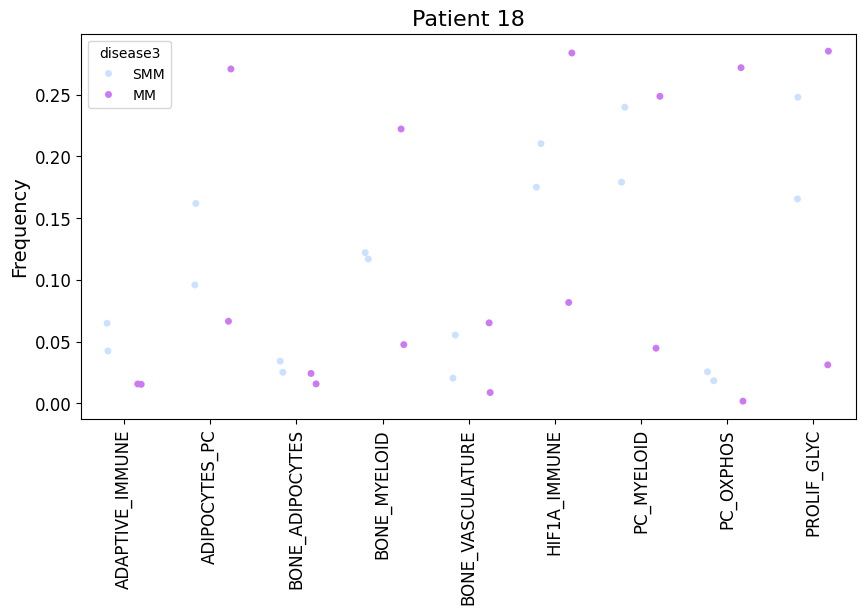

In [65]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='cellcharter_CN', y='value', hue='disease3', palette=disease3_color_map, hue_order=['SMM', 'MM'], dodge=True, jitter=True, size=5, ax=ax)
plt.xlabel('')
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.title('Patient 18', fontsize=16)

# Markers

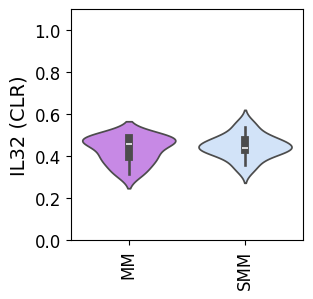

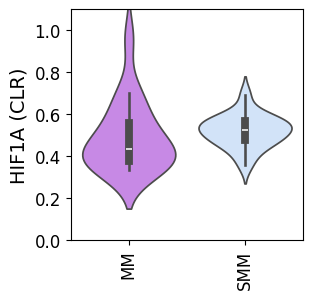

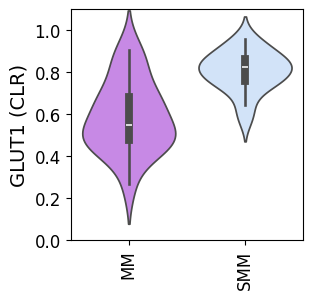

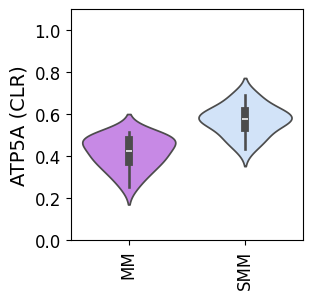

In [54]:
markers = ['IL32', 'HIF1A', 'GLUT1', 'ATP5A']
celltype = 'PCs'
cell = adata_p[adata_p.obs['Phenotype4'] == celltype]
#cell_subset = cell[cell.obs[f'cellcharter_CN'].isin(['PC_OXPHOS', 'PC_MYELOID', 'HIF1A_IMMUNE', 'ADAPTIVE_IMMUNE'])].copy()
df = cell.to_df()
df['cellcharter_CN'] = cell.obs['cellcharter_CN']
df['image_ID'] = cell.obs['image_ID']
df2 = df.groupby(['cellcharter_CN', 'image_ID']).median().reset_index().dropna()
df2['disease3'] = df2['image_ID'].map(disease_mapping.set_index('image_ID')['disease3'])
with plt.rc_context({"figure.figsize": (3, 3)}):
    for marker in markers:
        axes = sns.violinplot(x='disease3', y=marker, data=df2,
                              #hue = disease,
                              #hue_order=disease_order,
                              palette=disease3_color_map,
                              scale='width',
                              inner='box')
        axes.set_title(f'')
        
        # Get current y-axis limits
        ymin, ymax = axes.get_ylim()
        # Set new y-axis limits with 0.5 added to the max limit
        axes.set_ylim(0, 1.1)
        axes.set_xticklabels(axes.get_xticklabels(), rotation=90, fontsize=12)
        axes.set_yticklabels(axes.get_yticklabels(), fontsize=12)
        axes.set_ylabel(f'{marker} (CLR)', fontsize=14)
        axes.set_xlabel('')
        
        
        fig = axes.figure
        # fig.savefig(os.path.join(save_path, f'violin_{celltype}_{marker}_per_image_neighborhoods.{extension}'), 
        #             dpi=300, 
        #             bbox_inches='tight',
        #             pad_inches=0.1)
        plt.show()
        plt.close(fig)

# Interactions

In [91]:
interactions = pd.read_csv('//Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/downstream/COZI/250326COZI_phenotype4_normalized.csv')

In [92]:
interactions.rename(columns={'CD8+Tcells_Plasma Cells/MM cells': 'CD8 T*PCs', 'Plasma Cells/MM cells_CD8+Tcells': 'PCs*CD8 T','Plasma Cells/MM cells_CD4+Tcells': 'PCs*CD4 T',
                                'CD4+Tcells_Plasma Cells/MM cells': 'CD4 T*PCs', 'Plasma Cells/MM cells_Dendritic Cells': 'PCs*DCs', 'Dendritic Cells_Plasma Cells/MM cells': 'DCs*PCs',
                                'Plasma Cells/MM cells_Neutrophils': 'PCs*Neutrophils', 'Neutrophils_Plasma Cells/MM cells': 'Neutrophils*PCs',
                                'Plasma Cells/MM cells_activated Macrophages/Monocytes': 'PCs*HLA-DR+ Macs/monos', 'activated Macrophages/Monocytes_Plasma Cells/MM cells': 'HLA-DR+ Macs/monos*PCs',
                                'Plasma Cells/MM cells_Macrophages/Monocytes': 'PCs*Macs/monos', 'Macrophages/Monocytes_Plasma Cells/MM cells': 'Macs/monos*PCs',
                                'Plasma Cells/MM cells_Plasma Cells/MM cells': 'PCs*PCs'}, inplace=True)

In [76]:
interactions

,Unnamed: 0,Adipocytes_Adipocytes,Adipocytes_CD4+Tcells,Adipocytes_CD8+Tcells,Adipocytes_Dendritic Cells,Adipocytes_Endothelial cells,Adipocytes_HSCs,Adipocytes_MPO+,Adipocytes_Macrophages/Monocytes,Adipocytes_Neutrophils,...,activated Macrophages/Monocytes_HSCs,activated Macrophages/Monocytes_MPO+,activated Macrophages/Monocytes_Macrophages/Monocytes,activated Macrophages/Monocytes_Neutrophils,activated Macrophages/Monocytes_Osteoblast lineage,activated Macrophages/Monocytes_Osteoclasts,activated Macrophages/Monocytes_Osteocyte,HLA-DR+ Macs/monos*PCs,activated Macrophages/Monocytes_Unknown,activated Macrophages/Monocytes_activated Macrophages/Monocytes
0,TS-373_IMC77_B_001.csv,0.054949,-0.042442,-0.000054,NaN,0.006039,-0.026232,0.014985,0.060071,-0.051738,...,0.016857,0.019165,0.092099,-0.026314,-0.008306,-0.012124,-0.117433,0.114973,-0.032708,0.063877
1,TS-373_IMC03_MGUS_002.csv,0.005190,-0.011268,0.010453,0.027005,-0.003806,0.048618,0.002523,0.040293,0.008392,...,0.125139,0.033378,0.054758,-0.004918,-0.009374,-0.079879,0.015539,-0.011458,0.003187,0.296059
2,TS-373_IMC04_MGUS_002.csv,0.092674,-0.021724,0.026266,-0.007642,0.018563,0.041496,0.011489,0.009146,-0.017640,...,-0.010934,0.092349,0.091971,-0.025330,0.070175,-0.154794,-0.562354,0.056294,0.012091,0.288558
3,TS-373_IMC72_MGUS_001.csv,0.091440,-0.011927,-0.006493,0.015286,0.023676,0.019576,0.030488,0.000190,-0.032019,...,0.088556,0.048065,0.087024,-0.043034,0.020383,NaN,NaN,0.065993,0.002079,0.238335
4,TS-373_IMC12_UB_001.csv,0.017522,-0.000978,0.027636,0.022704,0.036517,-0.005331,0.021044,0.122594,0.025438,...,0.038852,0.023479,0.034604,0.019077,-0.003451,-0.015048,-0.054673,0.010244,0.020360,0.072932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,TS-373_IMC41_MGUS_001.csv,0.130174,-0.004946,0.003114,0.000584,-0.022812,-0.114765,0.067704,-0.011081,-0.047949,...,-0.006660,-0.007426,0.069986,-0.004997,0.001291,NaN,NaN,0.062232,0.021390,0.310782
148,TS-373_IMC87-1_UB_001.csv,0.151764,-0.002687,-0.002672,0.003690,0.021375,-0.003574,0.004219,-0.005765,0.007472,...,0.026489,0.050436,0.038971,0.080432,0.031366,NaN,NaN,0.002039,0.084110,0.156326
149,TS-373_IMC53_B_002.csv,0.177587,0.017003,0.049589,-0.003030,0.077515,-0.021291,0.011758,-0.003055,0.022034,...,0.051981,0.118476,0.001440,0.053857,-0.004224,-0.007753,-0.000644,-0.026546,0.048306,0.049889
150,TS-373_IMC47_B_002.csv,0.058939,-0.006602,-0.001844,0.002252,0.041461,-0.005442,0.013603,-0.042782,0.005282,...,0.054099,0.056749,0.040048,0.044577,0.109517,0.003230,-0.004668,0.054135,0.090577,0.092481


In [72]:
interactions['disease2'].unique()

array(['MM_BD', 'MM_noBD'], dtype=object)

In [94]:
interactions

,Unnamed: 0,Adipocytes_Adipocytes,Adipocytes_CD4+Tcells,Adipocytes_CD8+Tcells,Adipocytes_Dendritic Cells,Adipocytes_Endothelial cells,Adipocytes_HSCs,Adipocytes_MPO+,Adipocytes_Macrophages/Monocytes,Adipocytes_Neutrophils,...,activated Macrophages/Monocytes_HSCs,activated Macrophages/Monocytes_MPO+,activated Macrophages/Monocytes_Macrophages/Monocytes,activated Macrophages/Monocytes_Neutrophils,activated Macrophages/Monocytes_Osteoblast lineage,activated Macrophages/Monocytes_Osteoclasts,activated Macrophages/Monocytes_Osteocyte,HLA-DR+ Macs/monos*PCs,activated Macrophages/Monocytes_Unknown,activated Macrophages/Monocytes_activated Macrophages/Monocytes
0,TS-373_IMC77_B_001.csv,0.054949,-0.042442,-0.000054,NaN,0.006039,-0.026232,0.014985,0.060071,-0.051738,...,0.016857,0.019165,0.092099,-0.026314,-0.008306,-0.012124,-0.117433,0.114973,-0.032708,0.063877
1,TS-373_IMC03_MGUS_002.csv,0.005190,-0.011268,0.010453,0.027005,-0.003806,0.048618,0.002523,0.040293,0.008392,...,0.125139,0.033378,0.054758,-0.004918,-0.009374,-0.079879,0.015539,-0.011458,0.003187,0.296059
2,TS-373_IMC04_MGUS_002.csv,0.092674,-0.021724,0.026266,-0.007642,0.018563,0.041496,0.011489,0.009146,-0.017640,...,-0.010934,0.092349,0.091971,-0.025330,0.070175,-0.154794,-0.562354,0.056294,0.012091,0.288558
3,TS-373_IMC72_MGUS_001.csv,0.091440,-0.011927,-0.006493,0.015286,0.023676,0.019576,0.030488,0.000190,-0.032019,...,0.088556,0.048065,0.087024,-0.043034,0.020383,NaN,NaN,0.065993,0.002079,0.238335
4,TS-373_IMC12_UB_001.csv,0.017522,-0.000978,0.027636,0.022704,0.036517,-0.005331,0.021044,0.122594,0.025438,...,0.038852,0.023479,0.034604,0.019077,-0.003451,-0.015048,-0.054673,0.010244,0.020360,0.072932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,TS-373_IMC41_MGUS_001.csv,0.130174,-0.004946,0.003114,0.000584,-0.022812,-0.114765,0.067704,-0.011081,-0.047949,...,-0.006660,-0.007426,0.069986,-0.004997,0.001291,NaN,NaN,0.062232,0.021390,0.310782
148,TS-373_IMC87-1_UB_001.csv,0.151764,-0.002687,-0.002672,0.003690,0.021375,-0.003574,0.004219,-0.005765,0.007472,...,0.026489,0.050436,0.038971,0.080432,0.031366,NaN,NaN,0.002039,0.084110,0.156326
149,TS-373_IMC53_B_002.csv,0.177587,0.017003,0.049589,-0.003030,0.077515,-0.021291,0.011758,-0.003055,0.022034,...,0.051981,0.118476,0.001440,0.053857,-0.004224,-0.007753,-0.000644,-0.026546,0.048306,0.049889
150,TS-373_IMC47_B_002.csv,0.058939,-0.006602,-0.001844,0.002252,0.041461,-0.005442,0.013603,-0.042782,0.005282,...,0.054099,0.056749,0.040048,0.044577,0.109517,0.003230,-0.004668,0.054135,0.090577,0.092481


In [86]:
adata_p.obs['image_ID'].unique()

['TS-373_IMC18-2_UB_001.csv', 'TS-373_IMC18-1_MGUS_001.csv', 'TS-373_IMC18-2_UB_002.csv', 'TS-373_IMC18-1_MGUS_002.csv']
Categories (4, object): ['TS-373_IMC18-1_MGUS_001.csv', 'TS-373_IMC18-1_MGUS_002.csv', 'TS-373_IMC18-2_UB_001.csv', 'TS-373_IMC18-2_UB_002.csv']

In [95]:
interactions = interactions.set_index('Unnamed: 0')
interactions

,Adipocytes_Adipocytes,Adipocytes_CD4+Tcells,Adipocytes_CD8+Tcells,Adipocytes_Dendritic Cells,Adipocytes_Endothelial cells,Adipocytes_HSCs,Adipocytes_MPO+,Adipocytes_Macrophages/Monocytes,Adipocytes_Neutrophils,Adipocytes_Osteoblast lineage,...,activated Macrophages/Monocytes_HSCs,activated Macrophages/Monocytes_MPO+,activated Macrophages/Monocytes_Macrophages/Monocytes,activated Macrophages/Monocytes_Neutrophils,activated Macrophages/Monocytes_Osteoblast lineage,activated Macrophages/Monocytes_Osteoclasts,activated Macrophages/Monocytes_Osteocyte,HLA-DR+ Macs/monos*PCs,activated Macrophages/Monocytes_Unknown,activated Macrophages/Monocytes_activated Macrophages/Monocytes
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TS-373_IMC77_B_001.csv,0.054949,-0.042442,-0.000054,NaN,0.006039,-0.026232,0.014985,0.060071,-0.051738,0.014526,...,0.016857,0.019165,0.092099,-0.026314,-0.008306,-0.012124,-0.117433,0.114973,-0.032708,0.063877
TS-373_IMC03_MGUS_002.csv,0.005190,-0.011268,0.010453,0.027005,-0.003806,0.048618,0.002523,0.040293,0.008392,0.001783,...,0.125139,0.033378,0.054758,-0.004918,-0.009374,-0.079879,0.015539,-0.011458,0.003187,0.296059
TS-373_IMC04_MGUS_002.csv,0.092674,-0.021724,0.026266,-0.007642,0.018563,0.041496,0.011489,0.009146,-0.017640,-0.001366,...,-0.010934,0.092349,0.091971,-0.025330,0.070175,-0.154794,-0.562354,0.056294,0.012091,0.288558
TS-373_IMC72_MGUS_001.csv,0.091440,-0.011927,-0.006493,0.015286,0.023676,0.019576,0.030488,0.000190,-0.032019,0.002422,...,0.088556,0.048065,0.087024,-0.043034,0.020383,NaN,NaN,0.065993,0.002079,0.238335
TS-373_IMC12_UB_001.csv,0.017522,-0.000978,0.027636,0.022704,0.036517,-0.005331,0.021044,0.122594,0.025438,0.074433,...,0.038852,0.023479,0.034604,0.019077,-0.003451,-0.015048,-0.054673,0.010244,0.020360,0.072932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TS-373_IMC41_MGUS_001.csv,0.130174,-0.004946,0.003114,0.000584,-0.022812,-0.114765,0.067704,-0.011081,-0.047949,-0.028001,...,-0.006660,-0.007426,0.069986,-0.004997,0.001291,NaN,NaN,0.062232,0.021390,0.310782
TS-373_IMC87-1_UB_001.csv,0.151764,-0.002687,-0.002672,0.003690,0.021375,-0.003574,0.004219,-0.005765,0.007472,0.004119,...,0.026489,0.050436,0.038971,0.080432,0.031366,NaN,NaN,0.002039,0.084110,0.156326
TS-373_IMC53_B_002.csv,0.177587,0.017003,0.049589,-0.003030,0.077515,-0.021291,0.011758,-0.003055,0.022034,-0.005921,...,0.051981,0.118476,0.001440,0.053857,-0.004224,-0.007753,-0.000644,-0.026546,0.048306,0.049889


In [96]:
interactions = interactions[interactions.index.isin(adata_p.obs['image_ID'].unique())]

In [97]:
interactions

,Adipocytes_Adipocytes,Adipocytes_CD4+Tcells,Adipocytes_CD8+Tcells,Adipocytes_Dendritic Cells,Adipocytes_Endothelial cells,Adipocytes_HSCs,Adipocytes_MPO+,Adipocytes_Macrophages/Monocytes,Adipocytes_Neutrophils,Adipocytes_Osteoblast lineage,...,activated Macrophages/Monocytes_HSCs,activated Macrophages/Monocytes_MPO+,activated Macrophages/Monocytes_Macrophages/Monocytes,activated Macrophages/Monocytes_Neutrophils,activated Macrophages/Monocytes_Osteoblast lineage,activated Macrophages/Monocytes_Osteoclasts,activated Macrophages/Monocytes_Osteocyte,HLA-DR+ Macs/monos*PCs,activated Macrophages/Monocytes_Unknown,activated Macrophages/Monocytes_activated Macrophages/Monocytes
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TS-373_IMC18-2_UB_001.csv,0.224125,0.025977,0.014439,0.004962,0.047907,0.041318,-0.014675,-0.006134,-0.008053,-0.104989,...,0.005783,0.049843,0.001224,-0.002678,0.011123,NaN,-0.016732,0.032818,0.066712,0.006770
TS-373_IMC18-1_MGUS_001.csv,0.079852,0.009541,0.004532,-0.012331,0.024130,0.025705,0.029942,-0.010356,-0.020408,0.002596,...,0.065586,0.083628,0.131225,0.051295,-0.004290,0.021048,-0.007876,0.038882,0.012817,0.175354
TS-373_IMC18-2_UB_002.csv,0.131585,-0.016515,-0.006940,-0.014580,0.018275,0.035417,0.025666,0.010454,-0.068207,-0.039285,...,-0.005061,0.054601,0.062227,0.030425,0.004753,NaN,-0.027842,0.025082,-0.002169,0.057232
TS-373_IMC18-1_MGUS_002.csv,0.194925,-0.025516,-0.030661,0.011843,0.110122,-0.010073,0.068880,0.032508,-0.010711,0.002956,...,0.076863,0.025514,0.041974,0.066181,0.000643,NaN,-0.083948,0.039992,0.084504,0.059178


In [100]:
disease_mapping

,image_ID,disease3
0,TS-373_IMC18-2_UB_001.csv,MM
1,TS-373_IMC18-1_MGUS_001.csv,SMM
2,TS-373_IMC18-2_UB_002.csv,MM
3,TS-373_IMC18-1_MGUS_002.csv,SMM


In [101]:
interactions['disease3'] = interactions.index.map(disease_mapping.set_index('image_ID')['disease3'])

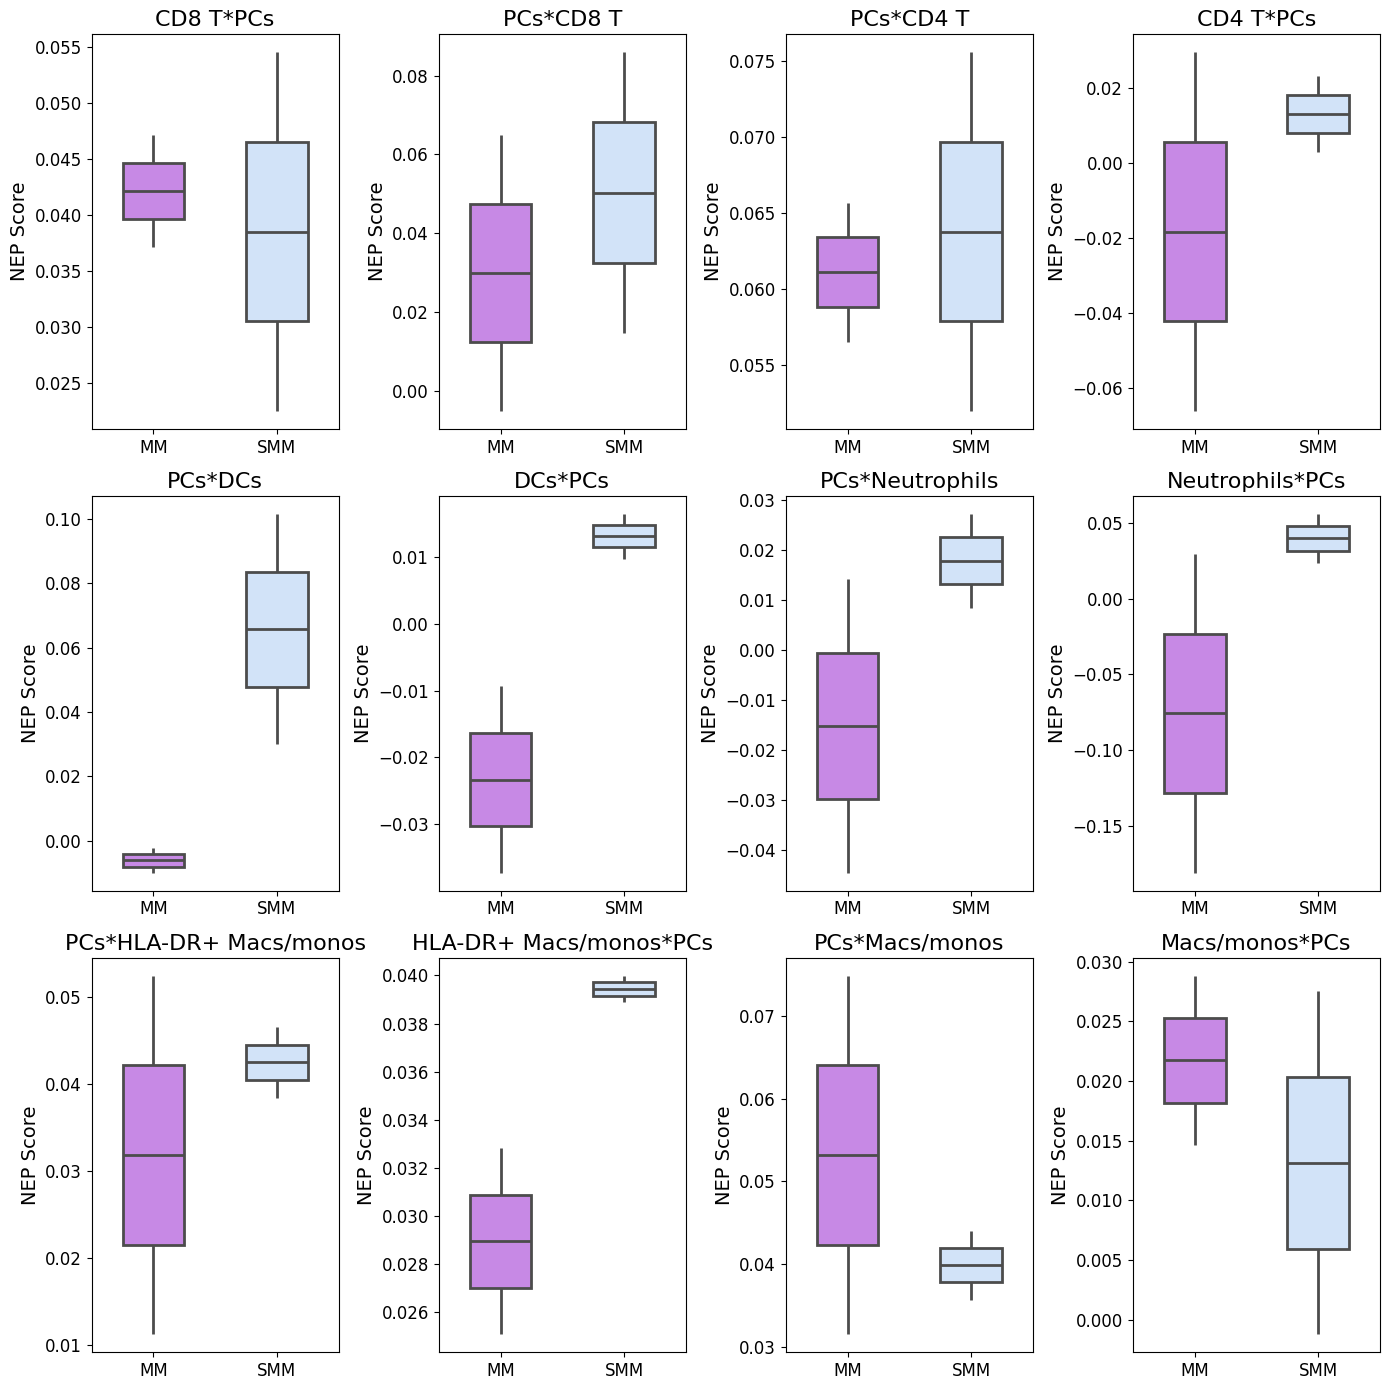

In [103]:
fig, ax = plt.subplots(3, 4, figsize=(14, 14))
order = ['long_PFS', 'short_PFS']
sns.boxplot(data=interactions, x='disease3', y='CD8 T*PCs', palette=disease3_color_map, ax=ax[0,0], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*CD8 T', palette=disease3_color_map, ax=ax[0,1], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*CD4 T', palette=disease3_color_map, ax=ax[0,2], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='CD4 T*PCs', palette=disease3_color_map, ax=ax[0,3], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*DCs', palette=disease3_color_map, ax=ax[1,0], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='DCs*PCs', palette=disease3_color_map, ax=ax[1,1], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*Neutrophils', palette=disease3_color_map, ax=ax[1,2], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='Neutrophils*PCs', palette=disease3_color_map, ax=ax[1,3], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*HLA-DR+ Macs/monos', palette=disease3_color_map, ax=ax[2,0], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='HLA-DR+ Macs/monos*PCs', palette=disease3_color_map, ax=ax[2,1], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='PCs*Macs/monos', palette=disease3_color_map, ax=ax[2,2], showcaps=False, linewidth=2, width=0.5)
sns.boxplot(data=interactions, x='disease3', y='Macs/monos*PCs', palette=disease3_color_map, ax=ax[2,3], showcaps=False, linewidth=2, width=0.5)
for axi in ax.flatten():
    axi.set_xlabel('')
    #titles = axi.get_ylabel().split('*')
    axi.set_title(axi.get_ylabel(), fontsize=16)
    axi.set_ylabel('NEP Score', fontsize=14)
    axi.set_xticklabels(axi.get_xticklabels(), fontsize=12)
    axi.set_yticklabels(axi.get_yticklabels(), fontsize=12)
plt.tight_layout()